<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/n%C3%A2ng_c%E1%BA%A5p__CNN_Flower_Version_4__l%C3%AAn_duoc_65_FEATURE_MAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Yêu cầu cụ thể: Mô hình CNN**


# MÔ HÌNH XÂY DỰNG

Input: 128 × 128 × 3

→ Conv2D (32 filters, 3×3) + ReLU
→ MaxPooling2D (2×2)

→ Conv2D (64 filters, 3×3) + ReLU
→ MaxPooling2D (2×2)

→ Flatten
→ Dense (128) + ReLU
→ Dense (5) + Softmax

- Conv2D: trích xuất đặc trưng (edges, textures, shapes)
- MaxPooling2D: giảm chiều dữ liệu, giữ đặc trưng quan trọng
- Flatten: chuyển tensor 2D → vector 1D
- Dense: học quan hệ phi tuyến để phân loại

# 🌸 BƯỚC 1 — IMPORT LIBRARIES

In [64]:
# ======================================================
# 1. IMPORT LIBRARIES
# ======================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# System operations
import os

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    average_precision_score
)

# Utility for multi-class PR Curve
from sklearn.preprocessing import label_binarize

# 📂 BƯỚC 2 HYPERPARAMETERS

In [3]:
# ==============================
# 2. HYPERPARAMETERS
# ==============================


IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 40
LEARNING_RATE = 0.0001


# 📂 BƯỚC 3 — LOAD DATA

In [4]:
# ======================================================
# 3. refact lần 2 - chốt - DATA ACQUISITION
# ======================================================

# ------------------------------------------------------
# 3.1 INSTALL & SETUP KAGGLE API
# ------------------------------------------------------

!pip install -q kaggle

from google.colab import files
files.upload()   # Upload kaggle.json

# Create Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy kaggle.json
!cp kaggle.json /root/.kaggle/

# Set permission
!chmod 600 /root/.kaggle/kaggle.json


# ------------------------------------------------------
# 3.2 DOWNLOAD DATASET
# ------------------------------------------------------

!kaggle datasets download -d alxmamaev/flowers-recognition


# ------------------------------------------------------
# 3.3 UNZIP DATASET
# ------------------------------------------------------

!unzip -q flowers-recognition.zip -d /content/


# ------------------------------------------------------
# 3.4 DEFINE DATASET PATH
# ------------------------------------------------------

base_dir = "/content/flowers"  # Corrected path

print("Dataset Path:", base_dir)
print("Classes:", os.listdir(base_dir))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:12<00:00, 18.4MB/s]

Dataset Path: /content/flowers
Classes: ['dandelion', 'tulip', 'rose', 'daisy', 'sunflower']


# 🧪 4. DATA PREPROCESSING & EXPLORATION

In [5]:
# ======================================================
# 4. DATA PREPROCESSING & EXPLORATION
# ======================================================

# ------------------------------------------------------
# 4.1 DATASET OVERVIEW
# ------------------------------------------------------

class_counts = {}

for folder in os.listdir(base_dir):

    folder_path = os.path.join(base_dir, folder)

    count = len(os.listdir(folder_path))

    class_counts[folder] = count


print("\nClasses and Number of Images:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")


Classes and Number of Images:
dandelion: 1052 images
tulip: 984 images
rose: 784 images
daisy: 764 images
sunflower: 733 images


<Figure size 800x500 with 0 Axes>

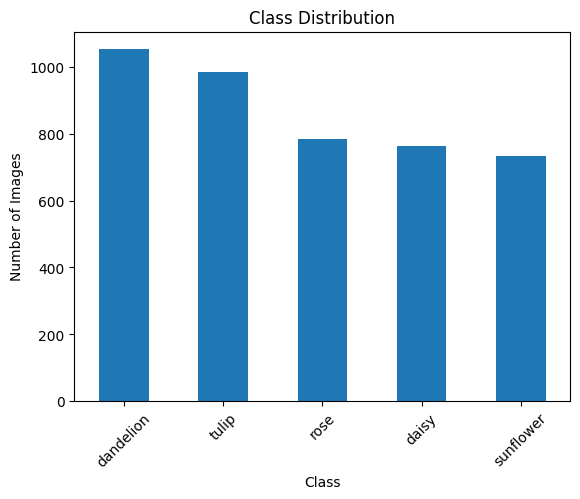

In [6]:
# ------------------------------------------------------
# 4.2 CLASS DISTRIBUTION
# ------------------------------------------------------
import pandas as pd
df = pd.DataFrame.from_dict(
    class_counts,
    orient='index',
    columns=['count']
)

plt.figure(figsize=(8,5))

df.plot(kind='bar', legend=False)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

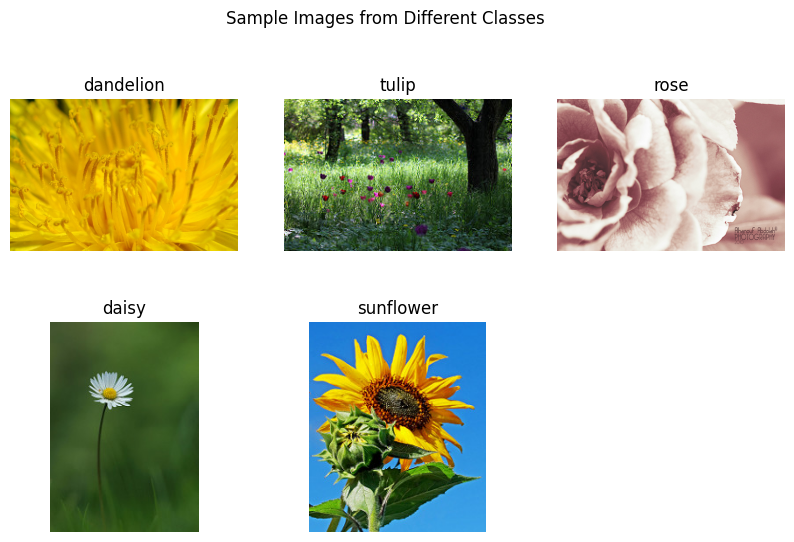

In [7]:
# ------------------------------------------------------
# 4.3 VISUALIZE SAMPLE IMAGES
# ------------------------------------------------------

plt.figure(figsize=(10,6))

for i, class_name in enumerate(list(class_counts.keys())[:6]):

    class_path = os.path.join(base_dir, class_name)

    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(class_name)

    plt.axis("off")


plt.suptitle("Sample Images from Different Classes")

plt.show()

In [8]:
# ------------------------------------------------------
# 4.4 DATA AUGMENTATION
# ------------------------------------------------------

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=30,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2
)

In [9]:
# ------------------------------------------------------
# 4.5 DATA GENERATOR
# ------------------------------------------------------

train_data = train_datagen.flow_from_directory(

    base_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)


val_data = train_datagen.flow_from_directory(

    base_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)


class_names = list(train_data.class_indices.keys())

num_classes = len(class_names)

print("\nClasses:", class_names)

print("Number of Classes:", num_classes)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of Classes: 5


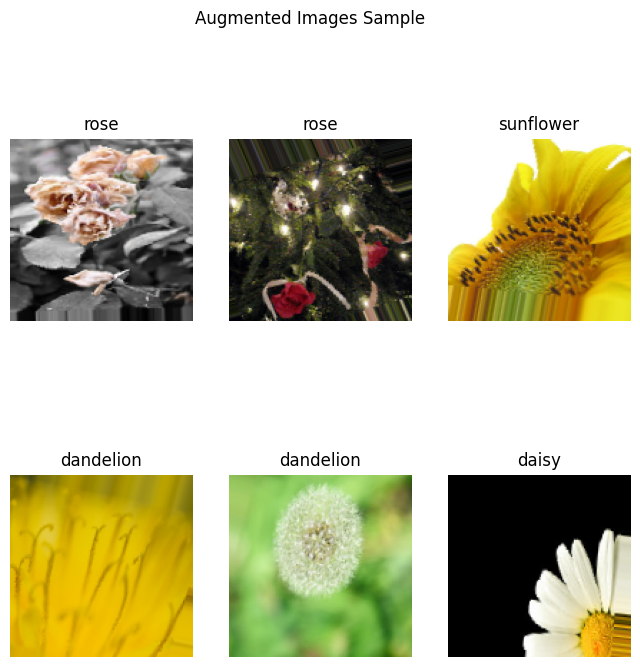

In [10]:
# ------------------------------------------------------
# 4.6 VISUALIZE AUGMENTED IMAGES
# ------------------------------------------------------

images, labels = next(train_data)

plt.figure(figsize=(8,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis('off')


plt.suptitle("Augmented Images Sample")

plt.show()

In [11]:
# ------------------------------------------------------
# 4.7 CHECK DATA SHAPE
# ------------------------------------------------------

print("\nBatch Shape:", images.shape)

print("Label Shape:", labels.shape)


Batch Shape: (32, 128, 128, 3)
Label Shape: (32, 5)


# **🧠 BƯỚC 5 — CNN MODEL BUILDING (FROM SCRATCH)**


## 🏋️ BƯỚC 5 — TRAINING + VISUALIZATION

In [12]:
# Code nâng cấp build CNN chiều ngay 7/5
# ------------------------------------------------------
# 5.1 BUILD CNN MODEL
# ------------------------------------------------------

model = models.Sequential([

    # ===== INPUT LAYER =====
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),


    # ===== CONV BLOCK 1 =====
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    # ===== CONV BLOCK 2 =====
    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    # ===== CONV BLOCK 3 =====
    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    # ===== FULLY CONNECTED LAYERS =====
    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])

In [ ]:
# ------------------------------------------------------
# 5.1 BUILD CNN MODEL
# ------------------------------------------------------

model = models.Sequential([

    # ===== INPUT LAYER =====
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),


    # ===== CONV BLOCK 1 =====
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    # ===== CONV BLOCK 2 =====
    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    # ===== CONV BLOCK 3 =====
    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    # ===== FULLY CONNECTED LAYERS =====
    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])

In [15]:
# ------------------------------------------------------
# 5.2 COMPILE MODEL
# ------------------------------------------------------
from tensorflow.keras.optimizers import Adam


optimizer = Adam(
    learning_rate=LEARNING_RATE
)

model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [16]:
# ------------------------------------------------------
# 5.3 MODEL SUMMARY
# ------------------------------------------------------

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,221 (16.36 MB)

 Trainable params: 4,288,773 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ------------------------------------------------------
# 5.4 MODEL ARCHITECTURE EXPLANATION
# ------------------------------------------------------

print("""
CNN Architecture Explanation:

1. Conv2D Layers:
   - Extract important image features such as edges,
     textures, petals, and flower shapes.

2. BatchNormalization:
   - Stabilizes and accelerates training process.

3. MaxPooling2D:
   - Reduces feature map dimensions and computation cost.

4. Flatten Layer:
   - Converts 2D feature maps into 1D feature vector.

5. Dense Layer:
   - Learns high-level representations for classification.

6. Dropout:
   - Reduces overfitting by randomly disabling neurons.

7. Softmax Output Layer:
   - Produces probability distribution across 5 flower classes.
""")


CNN Architecture Explanation:

1. Conv2D Layers:
   - Extract important image features such as edges,
     textures, petals, and flower shapes.

2. BatchNormalization:
   - Stabilizes and accelerates training process.

3. MaxPooling2D:
   - Reduces feature map dimensions and computation cost.

4. Flatten Layer:
   - Converts 2D feature maps into 1D feature vector.

5. Dense Layer:
   - Learns high-level representations for classification.

6. Dropout:
   - Reduces overfitting by randomly disabling neurons.

7. Softmax Output Layer:
   - Produces probability distribution across 5 flower classes.



# **📘  BƯỚC 6. MODEL TRAINING & EVALUATION**

In [17]:
# ======================================================
# 6. MODEL TRAINING & EVALUATION
# ======================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [18]:
# ------------------------------------------------------
# 6.1 DEFINE CALLBACKS
# ------------------------------------------------------

# Early stopping
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)


# Reduce learning rate
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.3,

    patience=2,

    min_lr=1e-6,

    verbose=1
)


# Save best model
checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor='val_loss',

    save_best_only=True,

    verbose=1
)

In [19]:
# ------------------------------------------------------
# 6.2 TRAIN MODEL
# ------------------------------------------------------

history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3707 - loss: 2.0948
Epoch 1: val_loss improved from None to 3.35829, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.4027 - loss: 1.6454 - val_accuracy: 0.2442 - val_loss: 3.3583 - learning_rate: 1.0000e-04
Epoch 2/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4480 - loss: 1.3009
Epoch 2: val_loss did not improve from 3.35829
109/109 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.4614 - loss: 1.2883 - val_accuracy: 0.2477 - val_loss: 5.4808 - learning_rate: 1.0000e-04
Epoch 3/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5011 - loss: 1.2136
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 3: val_loss did not improve from 3.35829
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.4944 - loss: 1.2374 - val_accuracy: 0.3314 - val_loss: 3.9327 - learning_rate: 1.0000e-04
E

# Mô hình CNN đang học đúng hướng vì:


loss giảm dần


val_loss giảm mạnh từ 6.98 → 1.06


val_accuracy tăng từ 27% → 52%




Learning rate được giảm tự động bởi ReduceLROnPlateau:


0.001 → 0.0003 → 0.00009


giúp mô hình học ổn định hơn ở các epoch sau.




Epoch tốt nhất hiện tại:


Theo val_loss: Epoch 11 (val_loss = 1.0646)


Theo val_accuracy: Epoch 14 (val_accuracy = 52.09%)




Mô hình chưa có dấu hiệu overfitting nghiêm trọng vì:


validation loss chưa tăng mạnh liên tục


validation accuracy vẫn còn tăng nhẹ.




Accuracy hiện tại khoảng 52%:


chưa cao nhưng chấp nhận được với CNN tự xây dựng từ đầu cho bài phân loại 5 loại hoa.


Pipeline huấn luyện nhìn chung hợp lý và đúng hướng học thuật.





#**🏋️ BƯỚC 7 ĐÁNH GIÁ MÔ HÌNH VÀ VISUALATION**
✅ 7.1 confusion matrix

✅ 7.2 classification report

✅ 7.3 PR curve

✅ 7.4 ACCURACY CURVE / LOSS CURVE

✅ 7.5 threshold analysis



# ✅ 7.1 CONFUSION MATRIX

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 276ms/step


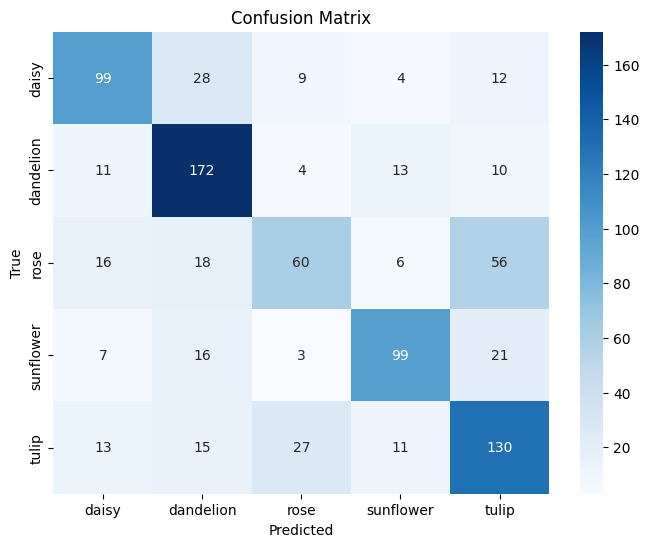

In [53]:
# BƯỚC 7 ĐÁNH GIÁ MÔ HÌNH VÀ VISUALATION

# 7.1 CONFUSION MATRIX

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict label
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ✅ 7.2 CLASSIFICATION REPORT

In [54]:
# 7.2 CLASSIFICATION REPORT chiều ngày 7/5
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

       daisy       0.68      0.65      0.66       152
   dandelion       0.69      0.82      0.75       210
        rose       0.58      0.38      0.46       156
   sunflower       0.74      0.68      0.71       146
       tulip       0.57      0.66      0.61       196

    accuracy                           0.65       860
   macro avg       0.65      0.64      0.64       860
weighted avg       0.65      0.65      0.64       860



#  ✅ 7.3 PR curve (PRECISION–RECALL)

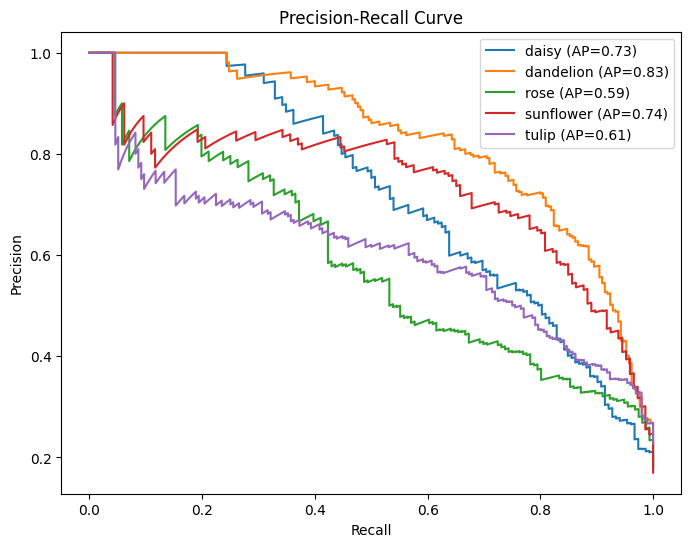

In [55]:
# 7.3 PR curve (PRECISION–RECALL) - chiều 7/5
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

#Plot PR Curve từng class
plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], Y_pred[:, i])
    ap = average_precision_score(y_true_bin[:, i], Y_pred[:, i])

    plt.plot(recall, precision, label=f"{class_names[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


# ✅  7.4 ACCURACY CURVE / LOSS CURVE



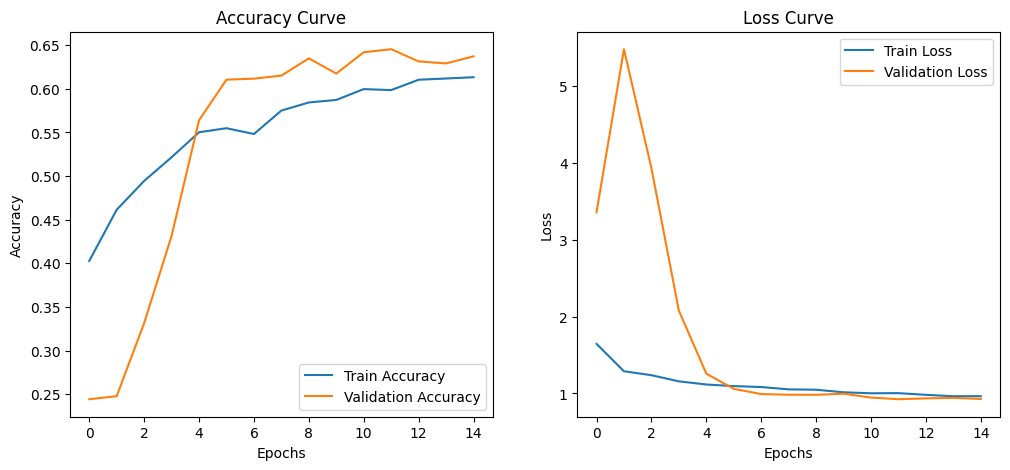

In [56]:
import matplotlib.pyplot as plt

# ==============================
# 7.4 ACCURACY & LOSS HISTORY
# ==============================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# ==============================
# 7.5. ACCURACY CURVE
# ==============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# ==============================
# 7.6. LOSS CURVE
# ==============================
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Giải thích callback và learning rate

## 1. EarlyStopping
EarlyStopping giúp dừng quá trình huấn luyện khi mô hình không còn cải thiện trên validation loss trong một số epoch liên tiếp. Điều này giúp tránh overfitting và tiết kiệm thời gian tính toán.

## 2. ReduceLROnPlateau
Khi validation loss không cải thiện, learning rate sẽ được giảm tự động. Việc giảm learning rate giúp mô hình học tinh chỉnh tốt hơn ở các vùng tối ưu nhỏ.

## 3. ModelCheckpoint
Callback này lưu lại mô hình có giá trị validation loss tốt nhất trong quá trình huấn luyện, đảm bảo không bị mất mô hình tốt nhất khi training tiếp tục.

## 4. Learning Rate
Learning rate điều khiển tốc độ cập nhật trọng số trong quá trình học:
- Learning rate lớn: học nhanh nhưng dễ dao động
- Learning rate nhỏ: học chậm nhưng ổn định và chính xác hơn

Trong bài này, learning rate được giảm dần từ 0.001 xuống các mức nhỏ hơn để giúp mô hình hội tụ tốt hơn.


# ✅  7.5 THRESHOLD ANALYSIS (1 CLASS EXAMPLE)

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 275ms/step


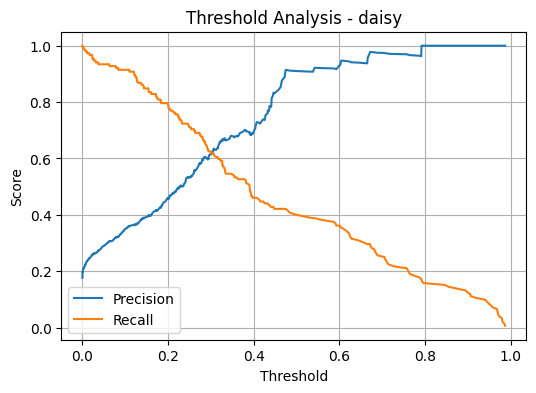

In [57]:
 # ======================================================
# 7.7 PREDICTION
# ======================================================

import numpy as np

y_true = val_data.classes
y_prob = model.predict(val_data)
y_pred = np.argmax(y_prob, axis=1)


 #======================================================
# 7.8 THRESHOLD ANALYSIS (1 CLASS EXAMPLE)
# ======================================================

# Chọn 1 class để minh họa (ví dụ class 0)
i = 0

precision, recall, thresholds = precision_recall_curve(
    y_true_bin[:, i],
    y_prob[:, i]
)

plt.figure(figsize=(6,4))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Threshold Analysis - {class_names[i]}")
plt.legend()
plt.grid(True)
plt.show()

# **🟣 SECTION 8 — FEATURE MAP VISUALIZATION**
✅FEATURE MAPS

✅ shallow/deep analysis

✅ tính tay parameters

# ✅ 8.1 FEATURE MAPS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


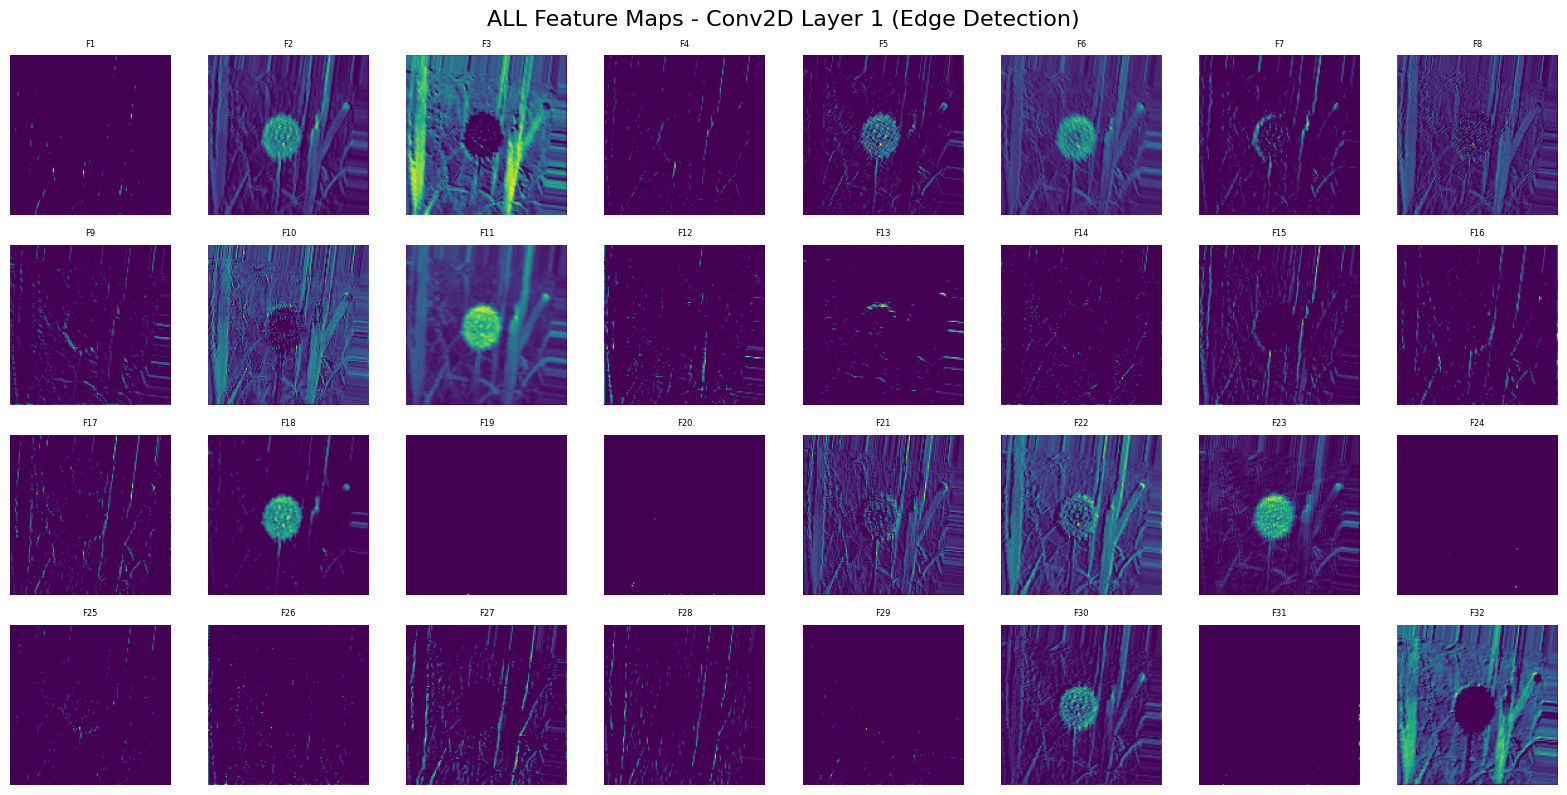

In [58]:
#   FEATURE MAPS
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# ==============================
#  8.1 GET CONV LAYER 1
# ==============================
conv_layer_1 = None

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_layer_1 = layer
        break

# ==============================
# 8.2. FEATURE MODEL
# ==============================
feature_model = Model(
    inputs=model.inputs,
    outputs=conv_layer_1.output
)

# ==============================
# 8.3. SAMPLE IMAGE
# ==============================
img_batch, _ = next(val_data)
img_sample = np.expand_dims(img_batch[0], axis=0)

# ==============================
# 8.4. FEATURE MAP OUTPUT
# ==============================
feature_map = feature_model.predict(img_sample)

# ==============================
# 8.5. VISUALIZE ALL MAPS
# ==============================
num_filters = feature_map.shape[-1]

cols = 8  # số cột hiển thị
rows = num_filters // cols + 1

plt.figure(figsize=(cols * 2, rows * 2))
plt.suptitle("ALL Feature Maps - Conv2D Layer 1 (Edge Detection)", fontsize=16)

for i in range(num_filters):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(feature_map[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f"F{i+1}", fontsize=6)

plt.tight_layout()
plt.show()

# ✅ 8.2 shallow/deep analysis

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


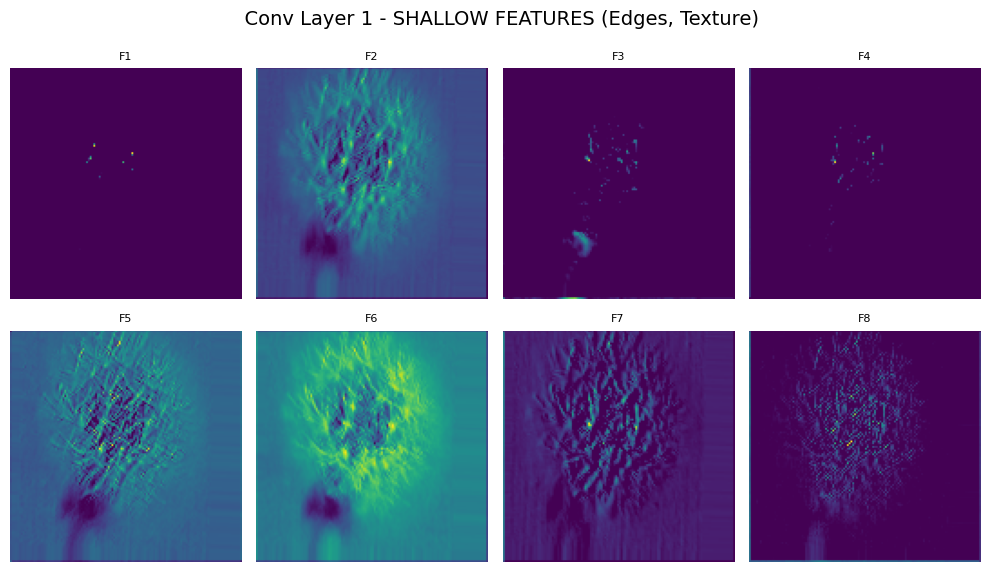

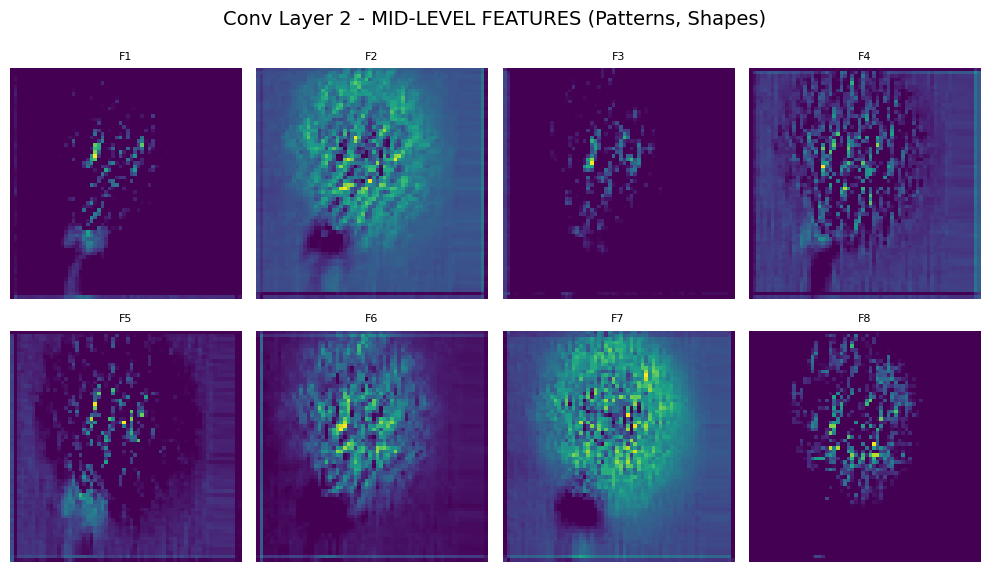

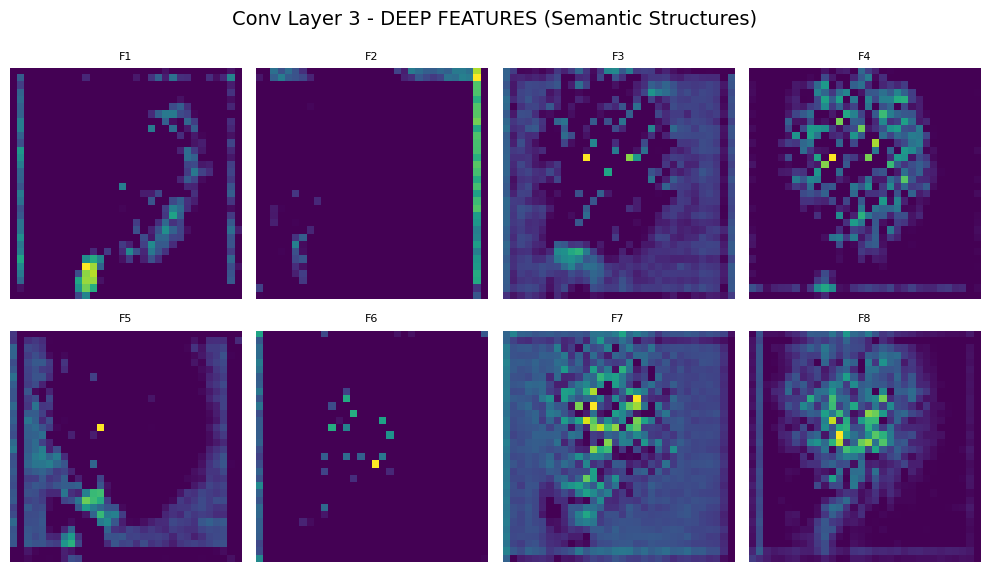

In [59]:
#  import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# ==============================
# 8.6. GET CONV LAYERS (1,2,3)
# ==============================
conv_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

selected_layers = conv_layers[:3]  # layer 1,2,3

# ==============================
# 8.7. BUILD FEATURE MODEL
# ==============================
feature_model = Model(
    inputs=model.inputs,
    outputs=[layer.output for layer in selected_layers]
)

# ==============================
# 8.8. SAMPLE IMAGE
# ==============================
img_batch, _ = next(val_data)
img_sample = np.expand_dims(img_batch[0], axis=0)

# ==============================
# 8.9. GET FEATURE MAPS
# ==============================
feature_maps = feature_model.predict(img_sample)

# ==============================
# 8.10. VISUALIZATION FUNCTION
# ==============================
def plot_feature_maps(feature_map, layer_name, max_filters=8):

    num_filters = feature_map.shape[-1]
    num_show = min(num_filters, max_filters)

    cols = 4
    rows = int(np.ceil(num_show / cols))

    plt.figure(figsize=(10, 6))
    plt.suptitle(layer_name, fontsize=14)

    for i in range(num_show):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_map[0, :, :, i], cmap='viridis')
        plt.axis('off')
        plt.title(f"F{i+1}", fontsize=8)

    plt.tight_layout()
    plt.show()

# ==============================
# 8.11 LAYER 1 - SHALLOW FEATURES
# ==============================
plot_feature_maps(
    feature_maps[0],
    "  Conv Layer 1 - SHALLOW FEATURES (Edges, Texture)"
)

# ==============================
# 8.12. LAYER 2 - MID FEATURES
# ==============================
plot_feature_maps(
    feature_maps[1],
    "Conv Layer 2 - MID-LEVEL FEATURES (Patterns, Shapes)"
)

# ==============================
# 8.13 LAYER 3 - DEEP FEATURES
# ==============================
plot_feature_maps(
    feature_maps[2],
    "Conv Layer 3 - DEEP FEATURES (Semantic Structures)"
)

# ✅ tính tay parameters

📌 Conv1

Input: 128×128×3
Kernel: 3×3

Output = (128 - 3)/1 + 1 = 126

📌 Conv2

Input: 126×126×32
Output = 124 × 124 × 64

📌 Conv3

(3×3×32 + 1) × 64 = 18496

#**# BƯỚC 9 SUMMARY METRICS**

In [61]:
# ==============================
# 9.1 SUMMARY METRICS
# ==============================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

summary = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, average='weighted'),
    "Recall": recall_score(y_true, y_pred, average='weighted'),
    "F1-Score": f1_score(y_true, y_pred, average='weighted')
}

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.6488
Precision: 0.6477
Recall: 0.6488
F1-Score: 0.6439


In [62]:
# ==============================
# 9.2. EXPORT REPORT
# ==============================

import pandas as pd

df_report = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
).transpose()

df_report.to_csv("classification_report.csv")

print("Saved report!")

Saved report!


In [63]:
# ==============================
# 9.3. MISCLASSIFIED SAMPLES
# ==============================

mis_idx = np.where(y_true != y_pred)[0]

print(f"Total misclassified: {len(mis_idx)}")

# xem thử 5 cái sai
for i in mis_idx[:5]:
    print(f"True: {class_names[y_true[i]]} | Pred: {class_names[y_pred[i]]}")

Total misclassified: 302
True: daisy | Pred: dandelion
True: daisy | Pred: dandelion
True: daisy | Pred: rose
True: daisy | Pred: rose
True: daisy | Pred: dandelion
